In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
df_asesor = pd.read_csv('/Users/ximenamarin/Desktop/extraccion_caracteristicas/Extraccion_de_Caracteristicas/Actividad4.2/Analisis GAC Full7agosto 2026(Ventas por Asesor ).csv')

In [12]:
df_asesor.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41
0,NaN,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ventas X Mes,12,7,8,13,6,21,17,17,23,...,NaN,178,NaN,397,NaN,236,NaN,NaN,NaN,NaN
2,NaN,Feb-24,Mar-24,Apr-24,May-24,Jun-24,Jul-24,Aug-24,Sep-24,Oct-24,...,NaN,2024,NaN,2025,NaN,2026,NaN,NaN,NaN,NaN
3,Nombre vendedor,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Raking,Acum,Ranking,Acum,Ranking,Acum,Ranking,NaN,NaN,NaN
4,PEDRO GONZALEZ ESPINDOLA,,,1,2,,7,2,3,3,...,2,22,3,45,3,21,4,NaN,NaN,NaN


In [14]:
data = df_asesor.iloc[5:56, 0:31].copy()
data.columns = ["Asesor"] + [f"mes_{i}" for i in range(1, 31)]
data["Asesor"] = data["Asesor"].str.strip()
 

In [15]:
columnas_meses = data.columns[1:]
data[columnas_meses] = data[columnas_meses].apply(
    pd.to_numeric, errors="coerce"
).fillna(0)

In [16]:
tabla_frecuencia = (
    data.assign(Total=data[columnas_meses].sum(axis=1))
    .loc[:, ["Asesor", "Total"]]
    .sort_values("Total", ascending=False)
    .reset_index(drop=True)
)
 
print(tabla_frecuencia.head(15))

                        Asesor  Total
0                Total general  811.0
1    JOSE ANTONIO LICONA MENDE   98.0
2   VICTOR MANUEL SANCHEZ ARRO   88.0
3   MAURICIO ALFREDO VAZQUEZ F   72.0
4    AURELIO FELIPE TORRES REV   63.0
5    ALAN GONZÁLEZ BELANZATEGU   46.0
6          JULIO CESAR PESTAÑA   29.0
7     MIGUEL ANGEL SONDEREGGER   28.0
8                PEDRO ANTONIO   26.0
9        JAIME GONZALEZ CORONA   25.0
10    NANCY OLASCOAGA CASTILLO   20.0
11         RICARDO SILVA HERAS   20.0
12  J4OSETTE RAMON NAVA FLORES   16.0
13   CARLOS ALBERTO NIETO MERI   15.0
14                     IGNACIO   14.0


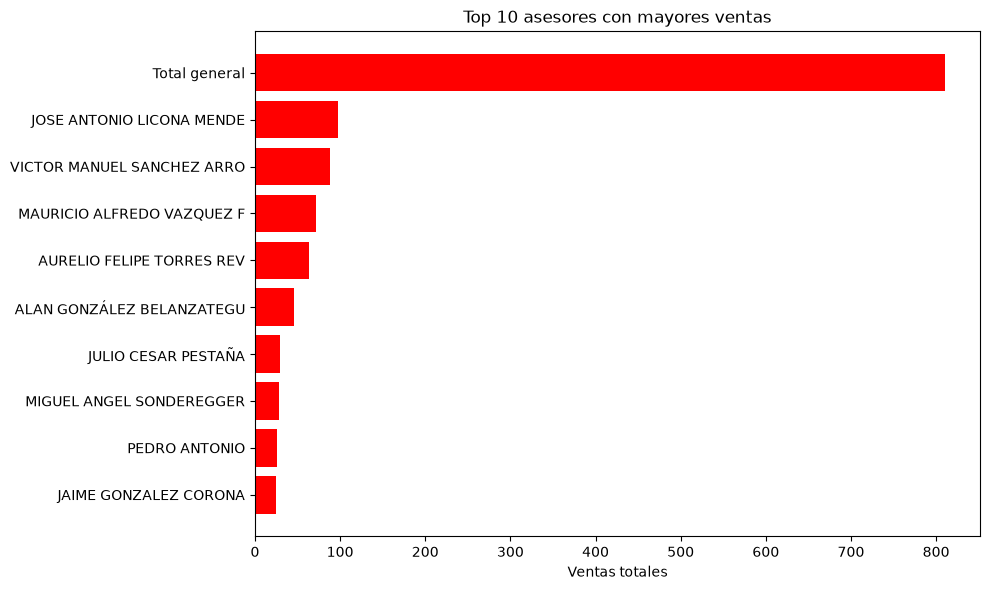

In [18]:
plt.figure(figsize=(10, 6))
plt.barh(top_n["Asesor"][::-1], top_n["Total"][::-1], color="red")
plt.xlabel("Ventas totales")
plt.title(f"Top {N} asesores con mayores ventas")
plt.tight_layout()
plt.savefig("top_asesores.png", dpi=150)
plt.show()

In [20]:
df = pd.read_csv('/Users/ximenamarin/Desktop/extraccion_caracteristicas/Extraccion_de_Caracteristicas/Actividad4.2/Analisis GAC Full7agosto 2026(Ventas por Asesor ).csv', header=None)

In [21]:
etiquetas_mes = df.iloc[3, 1:31].tolist()  # ej. 'Feb-24', 'Mar-24', ...
anios = ["20" + etiqueta.split("-")[1] for etiqueta in etiquetas_mes]  # '2024','2025','2026'

In [22]:
data = df.iloc[5:56, 0:31].copy()
data.columns = ["Asesor"] + [f"mes_{i}" for i in range(1, 31)]
data["Asesor"] = data["Asesor"].str.strip()
 
columnas_meses = data.columns[1:]
data[columnas_meses] = data[columnas_meses].apply(
    pd.to_numeric, errors="coerce"
).fillna(0)

In [23]:
for anio in ["2024", "2025", "2026"]:
    cols_anio = [c for c, a in zip(columnas_meses, anios) if a == anio]
    data[anio] = data[cols_anio].sum(axis=1)
 
data["Total"] = data[["2024", "2025", "2026"]].sum(axis=1)
 
tabla = (
    data[["Asesor", "2024", "2025", "2026", "Total"]]
    .sort_values("Total", ascending=False)
    .reset_index(drop=True)
)
 
print(tabla.head(10))
tabla.to_csv("tabla_frecuencia_por_anio.csv", index=False)

                       Asesor  2024  2025  2026  Total
0   JOSE ANTONIO LICONA MENDE  10.0  35.0  53.0   98.0
1    PEDRO GONZALEZ ESPINDOLA  22.0  45.0  21.0   88.0
2  VICTOR MANUEL SANCHEZ ARRO  11.0  51.0  26.0   88.0
3  MAURICIO ALFREDO VAZQUEZ F   0.0  47.0  25.0   72.0
4   AURELIO FELIPE TORRES REV   3.0  45.0  15.0   63.0
5   ALAN GONZÁLEZ BELANZATEGU   4.0  36.0   6.0   46.0
6         JULIO CESAR PESTAÑA   0.0  16.0  13.0   29.0
7    MIGUEL ANGEL SONDEREGGER  27.0   1.0   0.0   28.0
8               PEDRO ANTONIO   0.0  15.0  11.0   26.0
9       JAIME GONZALEZ CORONA  25.0   0.0   0.0   25.0


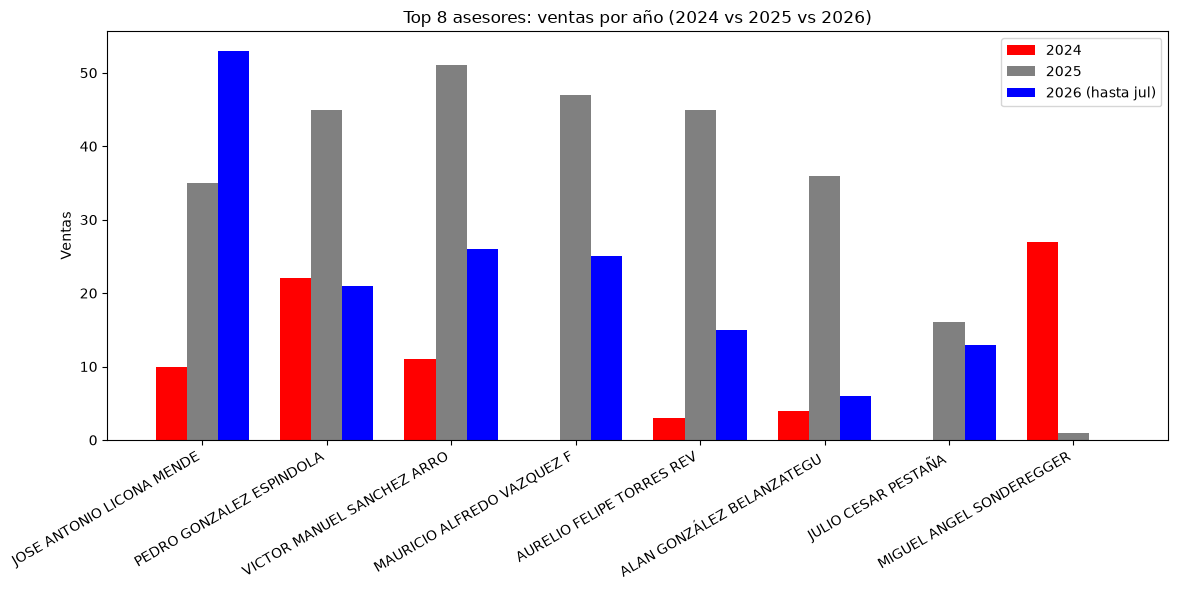

In [34]:
N = 8
top_n = tabla.head(N)
 
x = np.arange(len(top_n))
ancho = 0.25
 
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - ancho, top_n["2024"], width=ancho, label="2024", color="red")
ax.bar(x, top_n["2025"], width=ancho, label="2025", color="grey")
ax.bar(x + ancho, top_n["2026"], width=ancho, label="2026 (hasta jul)", color="blue")
 
ax.set_xticks(x)
ax.set_xticklabels(top_n["Asesor"], rotation=30, ha="right")
ax.set_ylabel("Ventas")
ax.set_title(f"Top {N} asesores: ventas por año (2024 vs 2025 vs 2026)")
ax.legend()
plt.tight_layout()
plt.savefig("comparativa_anios_asesores.png", dpi=150)
plt.show()

In [25]:
etiquetas_mes = df.iloc[3, 1:31].tolist()

In [26]:
data = df.iloc[5:56, 1:31].copy()
data.columns = etiquetas_mes
data = data.apply(pd.to_numeric, errors="coerce").fillna(0)

In [28]:
total_mensual = data.sum(axis=0)

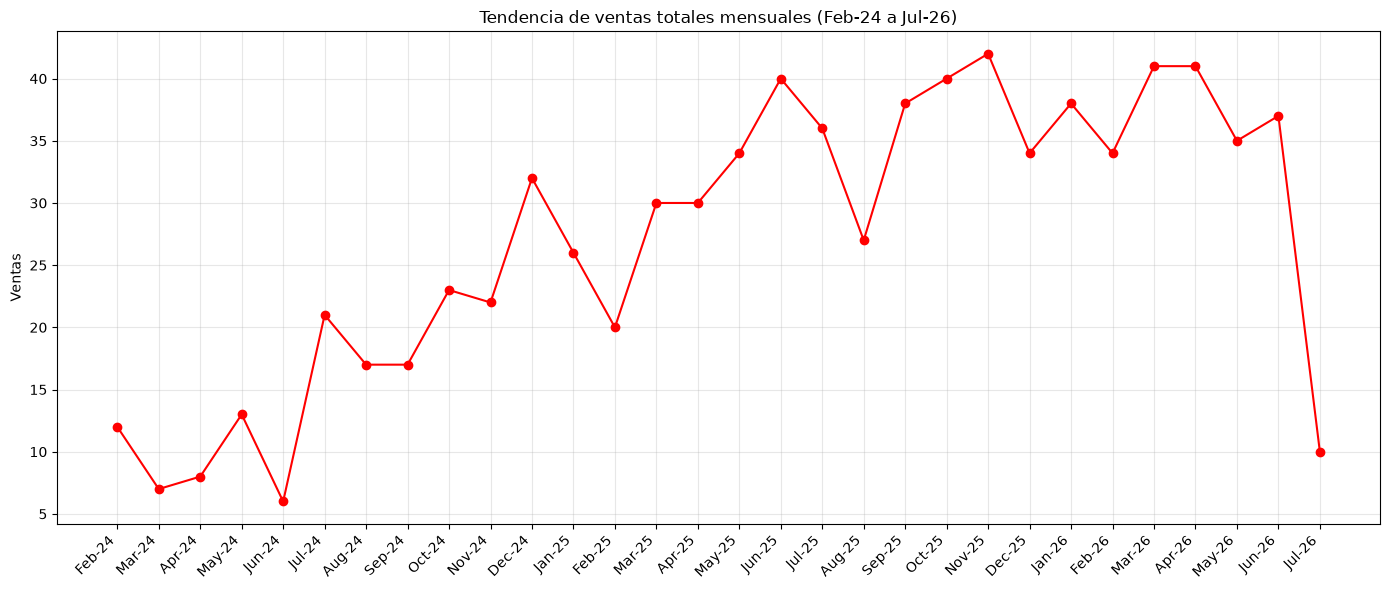

In [30]:
plt.figure(figsize=(14, 6))
plt.plot(total_mensual.index, total_mensual.values, marker="o", color="red")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Ventas")
plt.title("Tendencia de ventas totales mensuales (Feb-24 a Jul-26)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("tendencia_mensual.png", dpi=150)
plt.show()